In [1]:
import json
import os
import random
import sys
from copy import deepcopy
from pathlib import Path
import mlflow
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import spearmanr
from torch.utils.data import DataLoader, Dataset
from torch._higher_order_ops import scan
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / "guidance").exists() and (repo_root.parent / "guidance").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import corallab_stl.torch as stl
from corallab_stl.automata import get_spot_formula_and_aps

from guidance.label_world_model import add_labels
from guidance.utils.data import (
    DynamicsTransitionDataset,
    build_trajectory_dataset,
    collect_trajectories,
    compute_normalization_stats,
    get_demo_keys,
    split_trajectories,
)
from guidance.world_model_utils import (
    DynamicsMLP,
    build_state_from_obs_dict,
    deconstruct_state,
    load_model_for_eval,
    plot_rzz_world_model_branches,
    predict_next_state_from_raw,
    quat_to_6d,
    reconstruct_rotation_matrix_from_6d,
    rollout_policy_for_rzz_analysis,
    rzz_from_state_29d,
    xyzw_to_wxyz_batch,
)


In [ ]:
import h5py

# Open the file in read-only mode
with h5py.File('/home/shared/data/toy_squares/train/data.hdf5', 'r') as f:
    # Print the top-level keys
    print(list(f['data']['demo_0']['obs']['image'].shape))

[84, 128, 128, 3]


# Data Preparation

In [24]:
dataset_path = "/home/shared/data/toy_squares/train/data.hdf5"
demos = [(dataset_path, k) for k in get_demo_keys(dataset_path)]
trajectories = build_trajectory_dataset(
    demos,
    state_components=[
        lambda s: s["agent_pos"][:],
        lambda s: s["states"][:],  # blue, red, green, yellow
    ],
)

state_var = stl.Var(
    "state",
    dim=10,
    agent_pos=(0, 2),
    blue_pos=(2, 4),
    red_pos=(4, 6),
    green_pos=(6, 8),
    yellow_pos=(8, 10),
)

cube_radius = 0.2
at_blue = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[2:4]).norm(), 0.0)
at_red = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[4:6]).norm(), 0.0)
at_green = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[6:8]).norm(), 0.0)
at_yellow = stl.Predicate(state_var, lambda state, _: cube_radius - (state[0:2] - state[8:10]).norm(), 0.0)

trajectories = add_labels(trajectories, [at_green, at_blue, at_red, at_yellow])

print(f"Loaded {len(trajectories)} trajectories")
print(trajectories[0]["labels"].shape, trajectories[0]["next_labels"].shape)


Trajectory Dataset Summary:
 - Num trajectories: 10000
 - Num transitions:  588916
 - State dim:        10
 - Action dim:       2
Loaded 10000 trajectories
torch.Size([84, 4]) torch.Size([84, 4])



Processed 10000 trajectories
Trajectories with no nonzero label vector: 612
Most common offsets from the end: [(0, 3335), (1, 3284), (2, 1374), (3, 500), (4, 114), (5, 50), (17, 22), (32, 21), (22, 21), (8, 21)]


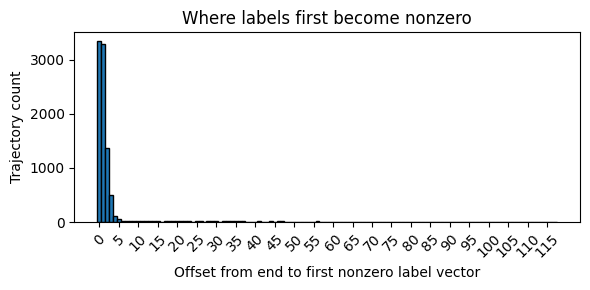

In [38]:
from collections import Counter

label_first_nonzero_indices = []
label_lengths = []
trajectories_with_no_nonzero = []

for traj_idx, traj in enumerate(trajectories):
    labels = np.asarray(traj["labels"])
    label_lengths.append(len(labels))

    if labels.ndim == 1:
        nonzero_mask = labels != 0
    else:
        nonzero_mask = np.any(labels != 0, axis=-1)

    nonzero_indices = np.flatnonzero(nonzero_mask)
    if len(nonzero_indices) == 0:
        trajectories_with_no_nonzero.append(traj_idx)
        label_first_nonzero_indices.append(None)
        # print(f"trajectory {traj_idx}: no nonzero label vector found")
    else:
        first_nonzero_idx = int(nonzero_indices[0])
        label_first_nonzero_indices.append(first_nonzero_idx)
        offset_from_end = len(labels) - first_nonzero_idx - 1
        # print(
        #     f"trajectory {traj_idx}: first nonzero label vector at index {first_nonzero_idx} "
        #     f"(offset from end = {offset_from_end})"
        # )

valid_offsets = [
    len(traj["labels"]) - idx - 1
    for traj, idx in zip(trajectories, label_first_nonzero_indices)
    if idx is not None
]

print()
print(f"Processed {len(trajectories)} trajectories")
print(f"Trajectories with no nonzero label vector: {len(trajectories_with_no_nonzero)}")

if valid_offsets:
    offset_counts = Counter(valid_offsets)
    print("Most common offsets from the end:", offset_counts.most_common(10))

    plt.figure(figsize=(6, 3))
    max_offset = max(valid_offsets)
    bins = np.arange(-0.5, max_offset + 1.5, 1.0)
    plt.hist(valid_offsets, bins=bins, edgecolor="black")
    plt.xlabel("Offset from end to first nonzero label vector")
    plt.ylabel("Trajectory count")
    plt.title("Where labels first become nonzero")
    tick_step = max(1, max_offset // 20)
    plt.xticks(range(0, max_offset + 1, tick_step), rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No trajectories with nonzero label vectors were found, so no histogram was plotted.")


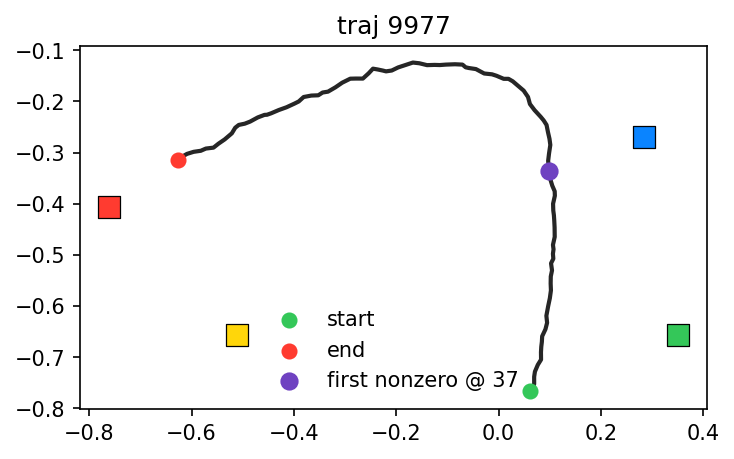

In [35]:
traj_idx = 9977
traj = trajectories[traj_idx]
states = np.asarray(traj["states"])
labels = np.asarray(traj["labels"])
agent = states[:, :2]
cubes = states[0, 2:10].reshape(4, 2)
first_nz = np.flatnonzero(np.any(labels != 0, axis=-1))

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.plot(agent[:, 0], agent[:, 1], c="black", lw=2, alpha=0.85)
ax.scatter(agent[0, 0], agent[0, 1], c="#34c759", s=45, label="start", zorder=3)
ax.scatter(agent[-1, 0], agent[-1, 1], c="#ff3b30", s=45, label="end", zorder=3)
ax.scatter(cubes[:, 0], cubes[:, 1], s=110, marker="s", c=["#0a84ff", "#ff3b30", "#34c759", "#ffd60a"], edgecolors="k", linewidths=0.6, zorder=2)
if len(first_nz):
    i = int(first_nz[0])
    ax.scatter(agent[i, 0], agent[i, 1], c="#6f42c1", s=60, label=f"first nonzero @ {i}", zorder=4)
else:
    ax.text(0.02, 0.98, "labels never become nonzero", transform=ax.transAxes, va="top")

ax.set_title(f"traj {traj_idx}")
ax.set_aspect("equal")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [76]:
split_seed = 42
train_trajectories, val_trajectories = split_trajectories(
    trajectories,
    val_ratio=0.2,
    seed=split_seed,
)

keys = ["states", "actions", "labels", "next_labels"]

# IMPORTANT: normalize using train split only
stats = compute_normalization_stats(train_trajectories, keys=keys)

train_dataset = DynamicsTransitionDataset(train_trajectories, stats, keys=keys, normalization_blacklist=["labels", "next_labels"])
val_dataset = DynamicsTransitionDataset(val_trajectories, stats, keys=keys, normalization_blacklist=["labels", "next_labels"])

Split Summary:
 - Total trajectories: 10000
 - Train trajectories: 8000
 - Val trajectories:   2000


In [77]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DataLoader setup for deterministic shuffling
batch_size = 256
loader_generator = torch.Generator()
loader_generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

In [78]:

batch = next(iter(train_loader))
print("Batch s_t:", batch["states"].shape)
print("Batch a_t:", batch["actions"].shape)
print("Batch label:", batch["labels"].shape)
print("Batch next_label:", batch["next_labels"].shape)
print(batch.keys())

Batch s_t: torch.Size([256, 10])
Batch a_t: torch.Size([256, 2])
Batch label: torch.Size([256, 4])
Batch next_label: torch.Size([256, 4])
dict_keys(['states', 'actions', 'labels', 'next_labels'])


# Automaton World Model Training 